In [3]:
import math
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM


In [5]:
# -------------------------
# Device + MPS helpers
# -------------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

def sync():
    if device.type == "mps":
        torch.mps.synchronize()

def mps_memory_mb():
    if device.type == "mps":
        alloc = torch.mps.current_allocated_memory() / (1024**2)
        driver = torch.mps.driver_allocated_memory() / (1024**2)
        return alloc, driver
    return 0.0, 0.0

def time_block(fn, warmup=10, iters=200, label=""):
    for _ in range(warmup):
        fn()
    sync()
    mem0 = mps_memory_mb()

    t0 = time.perf_counter()
    for _ in range(iters):
        fn()
    sync()
    t1 = time.perf_counter()

    mem1 = mps_memory_mb()
    avg_ms = (t1 - t0) * 1000 / iters
    print(f"{label:>18s}: {avg_ms:8.3f} ms/iter | MPS alloc {mem0[0]:.1f}->{mem1[0]:.1f} MB | driver {mem0[1]:.1f}->{mem1[1]:.1f} MB")
    return avg_ms

Using device: mps


In [7]:
# -------------------------
# Plot helper
# -------------------------
def plot_attention(A, tokens, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(A, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticklabels(tokens)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# -------------------------
# Token helper (NO FILTERS)
# -------------------------
def find_positions(tokens, token_str):
    return [i for i, t in enumerate(tokens) if t == token_str]

def top_targets(attn_map, tokens, token_str, occurrence=-1, k=10, label=""):
    pos = find_positions(tokens, token_str)
    if not pos:
        raise ValueError(f"Token '{token_str}' not found. Tokens: {tokens}")
    idx = pos[occurrence]
    row = attn_map[idx]
    top = np.argsort(-row)[:k]

    print(f"\n[{label}] token='{token_str}' idx={idx} row_sum={row.sum():.6f}")
    for j in top:
        print(f"  → {tokens[j]:>10s}: {row[j]:.8f}")  # more precision!

# -------------------------
# Attention core (causal)
# -------------------------
def build_causal_mask(T, device):
    return torch.triu(torch.ones(T, T, device=device, dtype=torch.bool), diagonal=1)

def attention_from_qkv(q, k, v):
    # q,k,v: (B,H,T,Dh)
    B, H, T, Dh = q.shape
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(Dh)   # (B,H,T,T)
    scores = scores.masked_fill(build_causal_mask(T, scores.device), float("-inf"))
    return torch.softmax(scores, dim=-1)

def share_kv(k, v, num_kv_heads):
    """
    MHA: num_kv_heads = H
    GQA: num_kv_heads divides H (e.g., 4 for H=12)
    MQA: num_kv_heads = 1
    We average K/V within each group then repeat back.
    """
    B, H, T, Dh = k.shape
    assert H % num_kv_heads == 0
    group = H // num_kv_heads

    k_g = k.view(B, num_kv_heads, group, T, Dh)
    v_g = v.view(B, num_kv_heads, group, T, Dh)

    k_m = k_g.mean(dim=2)  # (B, kv, T, Dh)
    v_m = v_g.mean(dim=2)

    k_exp = k_m.repeat_interleave(group, dim=1)  # (B, H, T, Dh)
    v_exp = v_m.repeat_interleave(group, dim=1)
    return k_exp, v_exp

In [9]:
# -------------------------
# Load GPT-2
# -------------------------
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

sentence = "The cat sat on the mat because it was tired."
enc = tokenizer(sentence, return_tensors="pt", add_special_tokens=False)
input_ids = enc["input_ids"].to(device)
attention_mask = enc["attention_mask"].to(device)

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
T = len(tokens)
print("Tokens:", tokens)

layer_idx = 5
head_idx = 3
GQA_KV_HEADS = 4  # must divide GPT-2 H=12

# -------------------------
# Forward for MHA "ground truth"
# -------------------------
with torch.no_grad():
    out = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_attentions=True,
        output_hidden_states=True,
        use_cache=False,
        return_dict=True
    )

# ✅ MHA baseline = model-returned attention
# (B,H,T,T)
attn_mha_true = out.attentions[layer_idx].detach()  # torch tensor


Tokens: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', 'Ġbecause', 'Ġit', 'Ġwas', 'Ġtired', '.']


`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


In [10]:
# -------------------------
# Compute Q,K,V (for GQA/MQA simulation)
# -------------------------
x_in = out.hidden_states[layer_idx].detach().to(device).float()    # (B,T,D)
ln_1 = model.transformer.h[layer_idx].ln_1
x_ln = ln_1(x_in)

B, T, D = x_ln.shape
H = model.config.n_head
Dh = D // H

gpt2_attn = model.transformer.h[layer_idx].attn
W_qkv = gpt2_attn.c_attn.weight.detach().to(device).float()  # (D,3D)
b_qkv = gpt2_attn.c_attn.bias.detach().to(device).float()    # (3D,)

qkv = x_ln @ W_qkv + b_qkv
q, k, v = torch.split(qkv, D, dim=-1)

q = q.view(B, T, H, Dh).transpose(1, 2).contiguous()
k = k.view(B, T, H, Dh).transpose(1, 2).contiguous()
v = v.view(B, T, H, Dh).transpose(1, 2).contiguous()

In [11]:
# -------------------------
# Build GQA / MQA attentions
# -------------------------
def run_gqa():
    k2, v2 = share_kv(k, v, num_kv_heads=GQA_KV_HEADS)
    return attention_from_qkv(q, k2, v2)

def run_mqa():
    k2, v2 = share_kv(k, v, num_kv_heads=1)
    return attention_from_qkv(q, k2, v2)

# Timing (note: MHA time here is from our compute version to be comparable)
def run_mha_compute():
    return attention_from_qkv(q, k, v)

print("\n--- Time + GPU memory (attention compute only) ---")
time_block(run_mha_compute, label="MHA (compute)")
time_block(run_gqa, label=f"GQA(kv={GQA_KV_HEADS})")
time_block(run_mqa, label="MQA(kv=1)")

with torch.no_grad():
    attn_mha_comp = run_mha_compute()  # should match model attentions closely
    attn_gqa = run_gqa()
    attn_mqa = run_mqa()


--- Time + GPU memory (attention compute only) ---
     MHA (compute):    0.228 ms/iter | MPS alloc 491.8->491.8 MB | driver 1082.7->1082.7 MB
         GQA(kv=4):    0.320 ms/iter | MPS alloc 491.8->491.8 MB | driver 1082.7->1082.7 MB
         MQA(kv=1):    0.322 ms/iter | MPS alloc 491.8->491.8 MB | driver 1082.7->1082.7 MB


In [12]:
# -------------------------
# Sanity check: does our MHA compute match model attention?
# -------------------------
A_true = attn_mha_true[0, head_idx].detach().float().cpu().numpy()
A_comp = attn_mha_comp[0, head_idx].detach().float().cpu().numpy()
diff = np.abs(A_true - A_comp)
print("\n--- Sanity check (MHA true vs MHA computed) ---")
print(f"Max abs diff:  {diff.max():.8f}")
print(f"Mean abs diff: {diff.mean():.8f}")


--- Sanity check (MHA true vs MHA computed) ---
Max abs diff:  0.00000000
Mean abs diff: 0.00000000


In [13]:
# -------------------------
# Prepare maps for plotting + top targets
# -------------------------
A_mha_head = attn_mha_true[0, head_idx].detach().float().cpu().numpy()     # ground truth
A_gqa_head = attn_gqa[0, head_idx].detach().float().cpu().numpy()
A_mqa_head = attn_mqa[0, head_idx].detach().float().cpu().numpy()

A_mha_avg = attn_mha_true[0].mean(dim=0).detach().float().cpu().numpy()
A_gqa_avg = attn_gqa[0].mean(dim=0).detach().float().cpu().numpy()
A_mqa_avg = attn_mqa[0].mean(dim=0).detach().float().cpu().numpy()

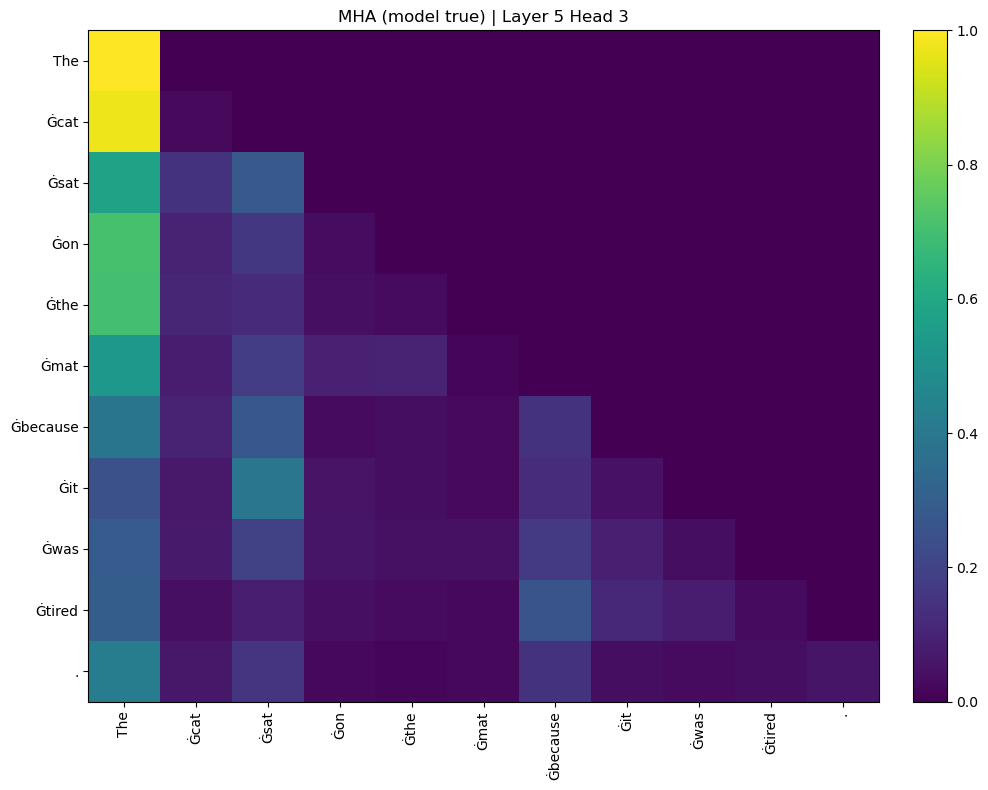

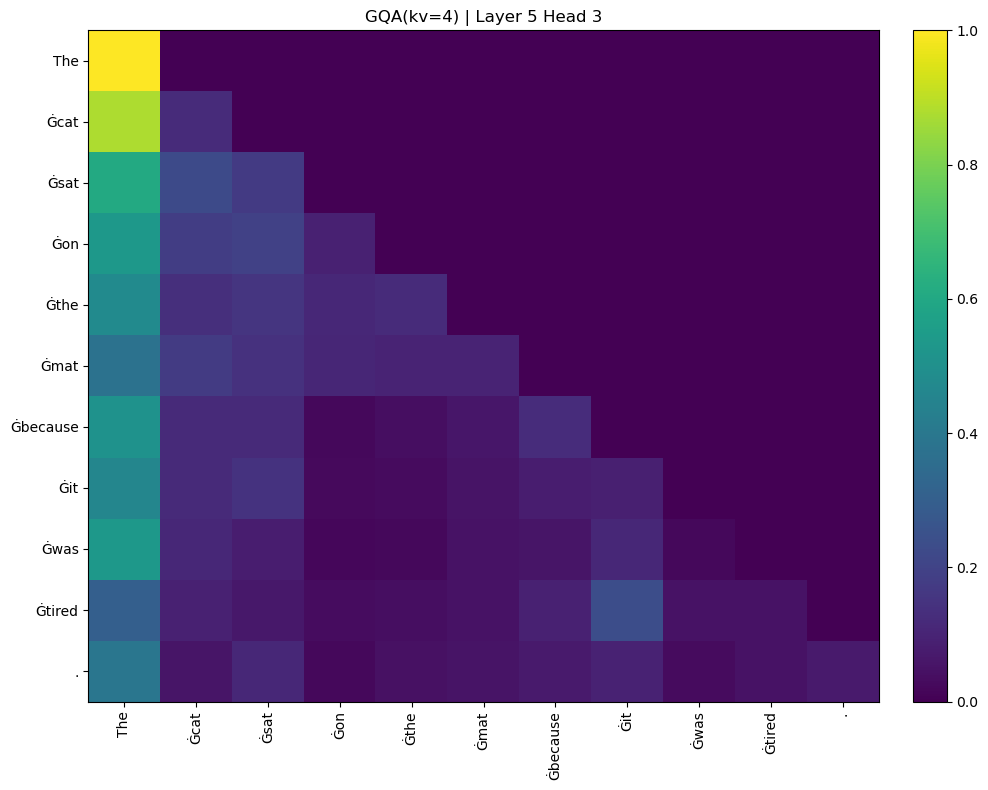

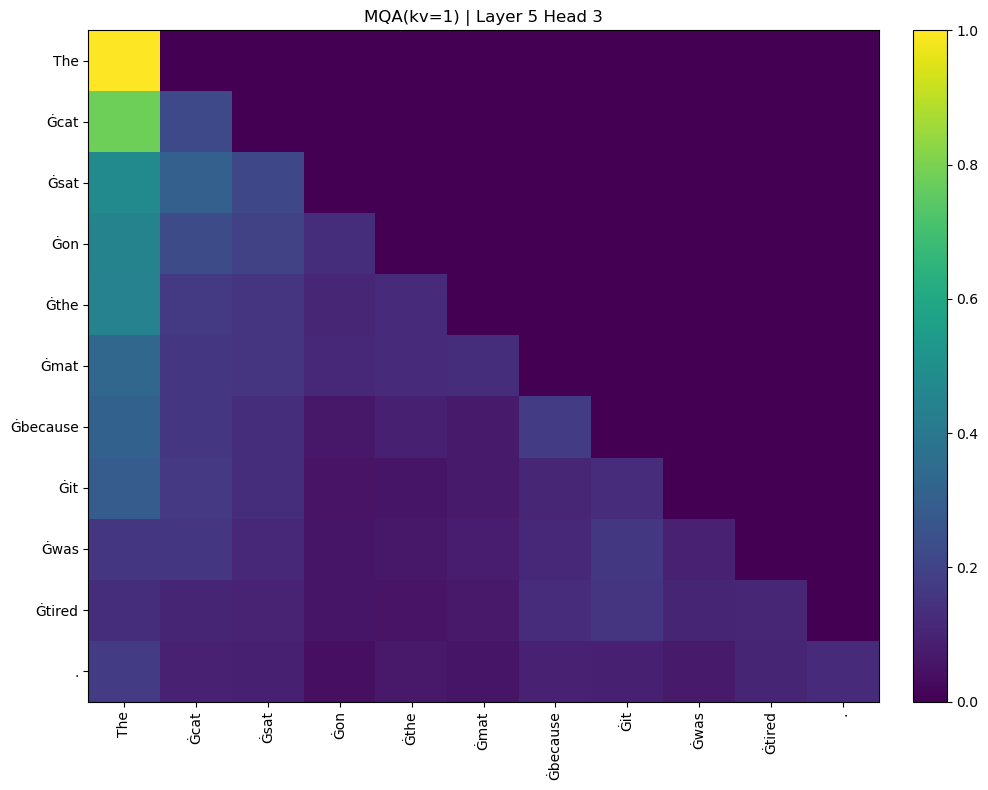

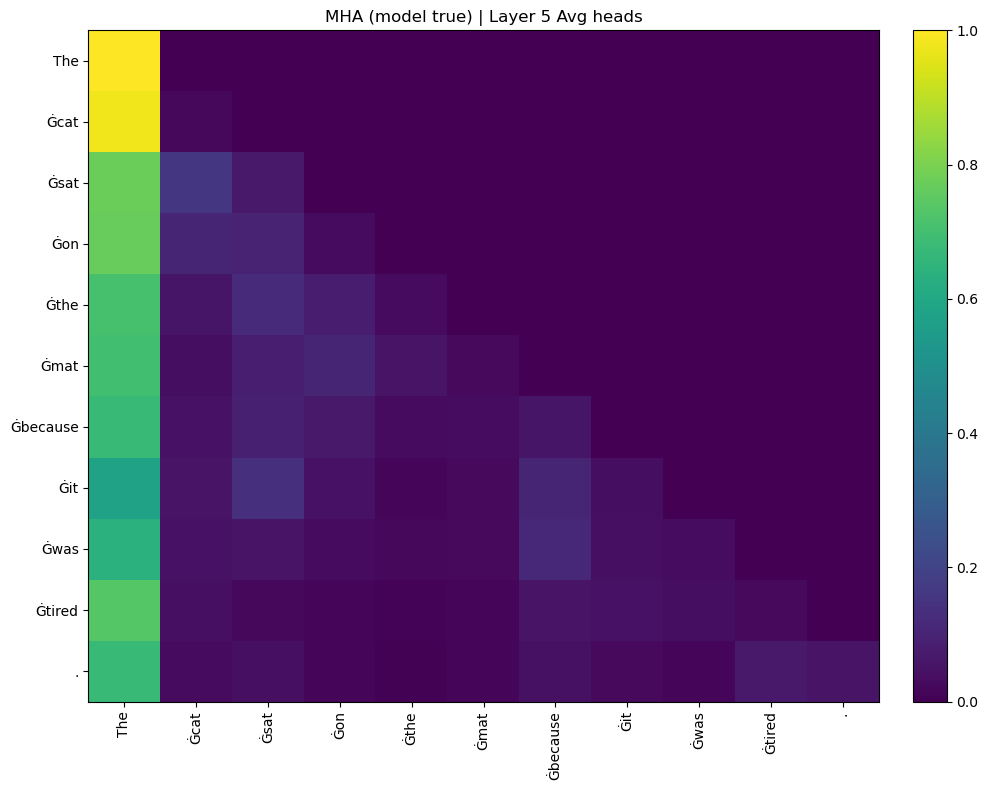

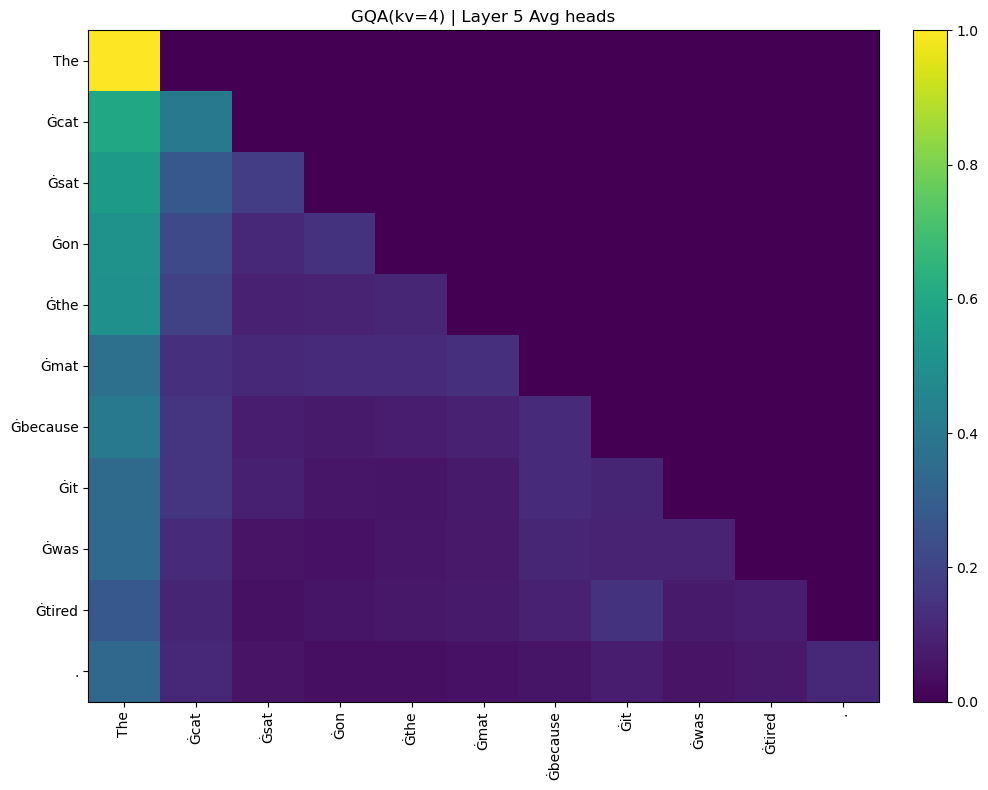

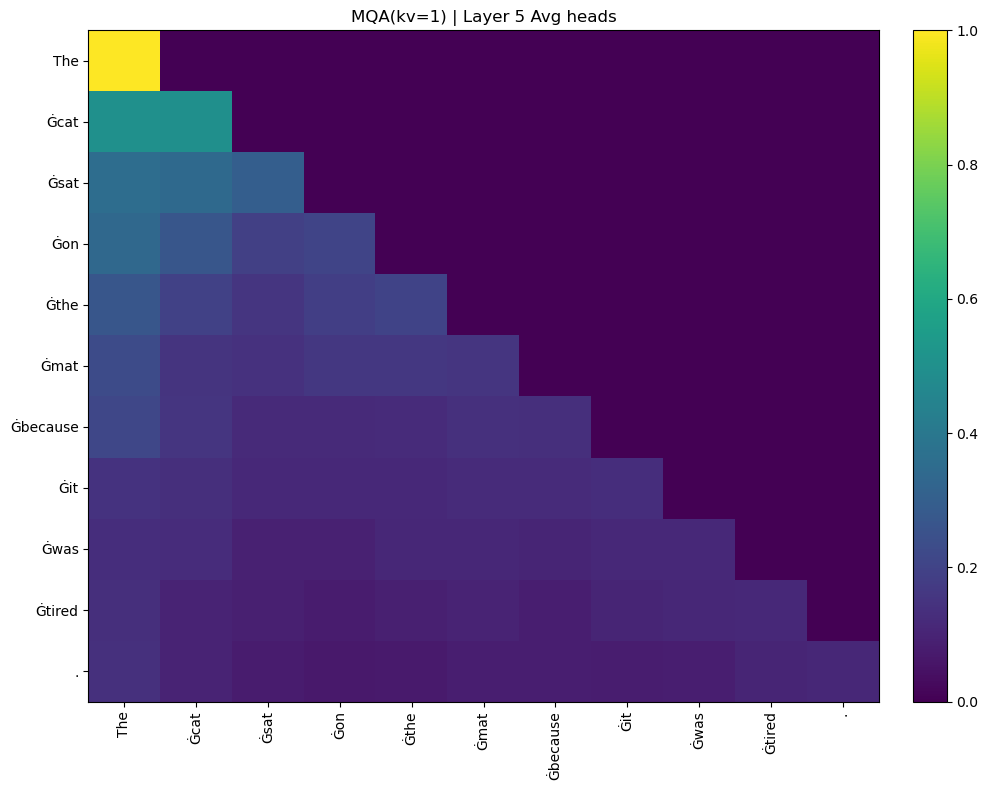


All positions of 'Ġit': [7]

--- Top targets from token (Avg map, compare mechanisms) ---

[MHA(true avg)] token='Ġit' idx=7 row_sum=1.000000
  →        The: 0.57724380
  →       Ġsat: 0.13627966
  →   Ġbecause: 0.10506142
  →       Ġcat: 0.05239473
  →        Ġon: 0.04885566
  →        Ġit: 0.03549619
  →       Ġmat: 0.02589268
  →       Ġthe: 0.01877586
  →       Ġwas: 0.00000000
  →     Ġtired: 0.00000000

[GQA(avg kv=4)] token='Ġit' idx=7 row_sum=1.000000
  →        The: 0.34570935
  →       Ġcat: 0.15293913
  →   Ġbecause: 0.11929941
  →        Ġit: 0.10452835
  →       Ġsat: 0.08935937
  →       Ġmat: 0.07414717
  →        Ġon: 0.05931183
  →       Ġthe: 0.05470537
  →       Ġwas: 0.00000000
  →     Ġtired: 0.00000000

[MQA(avg kv=1)] token='Ġit' idx=7 row_sum=1.000000
  →        The: 0.14518614
  →       Ġcat: 0.13410389
  →        Ġit: 0.13149925
  →       Ġmat: 0.12448404
  →   Ġbecause: 0.12135905
  →       Ġthe: 0.11523980
  →       Ġsat: 0.11481345
  →        Ġon: 0.113314

In [14]:
# -------------------------
# Plot heatmaps (same layer/head across mechanisms)
# -------------------------
plot_attention(A_mha_head, tokens, f"MHA (model true) | Layer {layer_idx} Head {head_idx}")
plot_attention(A_gqa_head, tokens, f"GQA(kv={GQA_KV_HEADS}) | Layer {layer_idx} Head {head_idx}")
plot_attention(A_mqa_head, tokens, f"MQA(kv=1) | Layer {layer_idx} Head {head_idx}")

plot_attention(A_mha_avg, tokens, f"MHA (model true) | Layer {layer_idx} Avg heads")
plot_attention(A_gqa_avg, tokens, f"GQA(kv={GQA_KV_HEADS}) | Layer {layer_idx} Avg heads")
plot_attention(A_mqa_avg, tokens, f"MQA(kv=1) | Layer {layer_idx} Avg heads")

# -------------------------
# Top targets (NO FILTERS) with precision
# -------------------------
token_str = "Ġit" if "Ġit" in tokens else "it"
print(f"\nAll positions of '{token_str}': {find_positions(tokens, token_str)}")

print("\n--- Top targets from token (Avg map, compare mechanisms) ---")
top_targets(A_mha_avg, tokens, token_str, k=10, label="MHA(true avg)")
top_targets(A_gqa_avg, tokens, token_str, k=10, label=f"GQA(avg kv={GQA_KV_HEADS})")
top_targets(A_mqa_avg, tokens, token_str, k=10, label="MQA(avg kv=1)")
